In [1]:
from ucimlrepo import fetch_ucirepo 
  
iris = fetch_ucirepo(id=53) 
  
features = iris.data.features 
targets = iris.data.targets 

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

feature_names = ["sepal length", "sepal width", "petal length", "petal width"]

df = pd.DataFrame(features, columns=[f'{feature_names[i]}' for i in range(features.shape[1])])
df['target'] = targets

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=42)

shuffled_indices = np.random.permutation(df.index)
train_indices = shuffled_indices[:int(len(shuffled_indices) * 0.8)]
train_data = df.loc[train_indices]
test_data = df.drop(train_indices)

print(f"Размер исходного набора данных: {len(df)}")
print(f"Размер обучающего множества: {len(X_train)}")
print(f"Размер тестового множества: {len(X_test)}")
X_train

Размер исходного набора данных: 150
Размер обучающего множества: 120
Размер тестового множества: 30


,sepal length,sepal width,petal length,petal width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [9]:
def df_metadata(df):
    num_rows = len(df)
        
    print(f"\nКоличество строк во множестве: {num_rows}")
        
    class_counts = df['target'].value_counts()
    print("\nКоличество объектов в каждом классе:")
    print(class_counts)
        
    missing_values_count = df.isna().sum()
    print("\nКоличество пропущенных значений:")
    print(missing_values_count)
        
    stats = df.describe()
    print("\nСтатистика для каждого параметра:")
    print(stats)

df_metadata(train_data)
#df_metadata(test_data)


Количество строк во множестве: 120

Количество объектов в каждом классе:
target
Iris-setosa        44
Iris-versicolor    39
Iris-virginica     37
Name: count, dtype: int64

Количество пропущенных значений:
sepal length    0
sepal width     0
petal length    0
petal width     0
target          0
dtype: int64

Статистика для каждого параметра:
       sepal length  sepal width  petal length  petal width
count    120.000000   120.000000    120.000000   120.000000
mean       5.796667     3.057500      3.647500     1.142500
std        0.852079     0.422212      1.798364     0.770208
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.500000     0.200000
50%        5.700000     3.000000      4.200000     1.300000
75%        6.400000     3.325000      5.100000     1.800000
max        7.900000     4.200000      6.900000     2.500000


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def print_report(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Точность модели на обучающем множестве: {accuracy:.5f}")

    report = classification_report(y_test, y_pred)
    print("\nОтчет о классификации:")
    print(report)

    conf_mat = confusion_matrix(y_test, y_pred)
    print("\nМатрица ошибок:")
    print(conf_mat)

def predict(x, y, x_test):
    gnb = GaussianNB()
    gnb.fit(x, y)
    return gnb.predict(x_test)

print_report(y_test, predict(X_train, y_train, X_test))

Точность модели на обучающем множестве: 1.00000

Отчет о классификации:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Матрица ошибок:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


d:\python_projects\ML\lab2\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
def get_specific_features(selected_features):
    all_features = list(iris.data.features.columns)

    feature_indices = {name: i for i, name in enumerate(all_features)}

    X = iris.data.features.iloc[:, [feature_indices[feat] for feat in selected_features]]
    y = iris.data.targets
    return train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_train, X_test, y_train, y_test = get_specific_features(['sepal length', 'sepal width'])
print_report(y_test, predict(X_train, y_train, X_test))

Точность модели на обучающем множестве: 0.90000

Отчет о классификации:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.88      0.78      0.82         9
 Iris-virginica       0.83      0.91      0.87        11

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


Матрица ошибок:
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]


d:\python_projects\ML\lab2\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Точность модели на обучающем множестве: 0.63333

Отчет о классификации:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.90      0.95        10
Iris-versicolor       0.40      0.44      0.42         9
 Iris-virginica       0.55      0.55      0.55        11

       accuracy                           0.63        30
      macro avg       0.65      0.63      0.64        30
   weighted avg       0.65      0.63      0.64        30


Матрица ошибок:
[[9 1 0]
 [0 4 5]
 [0 5 6]]


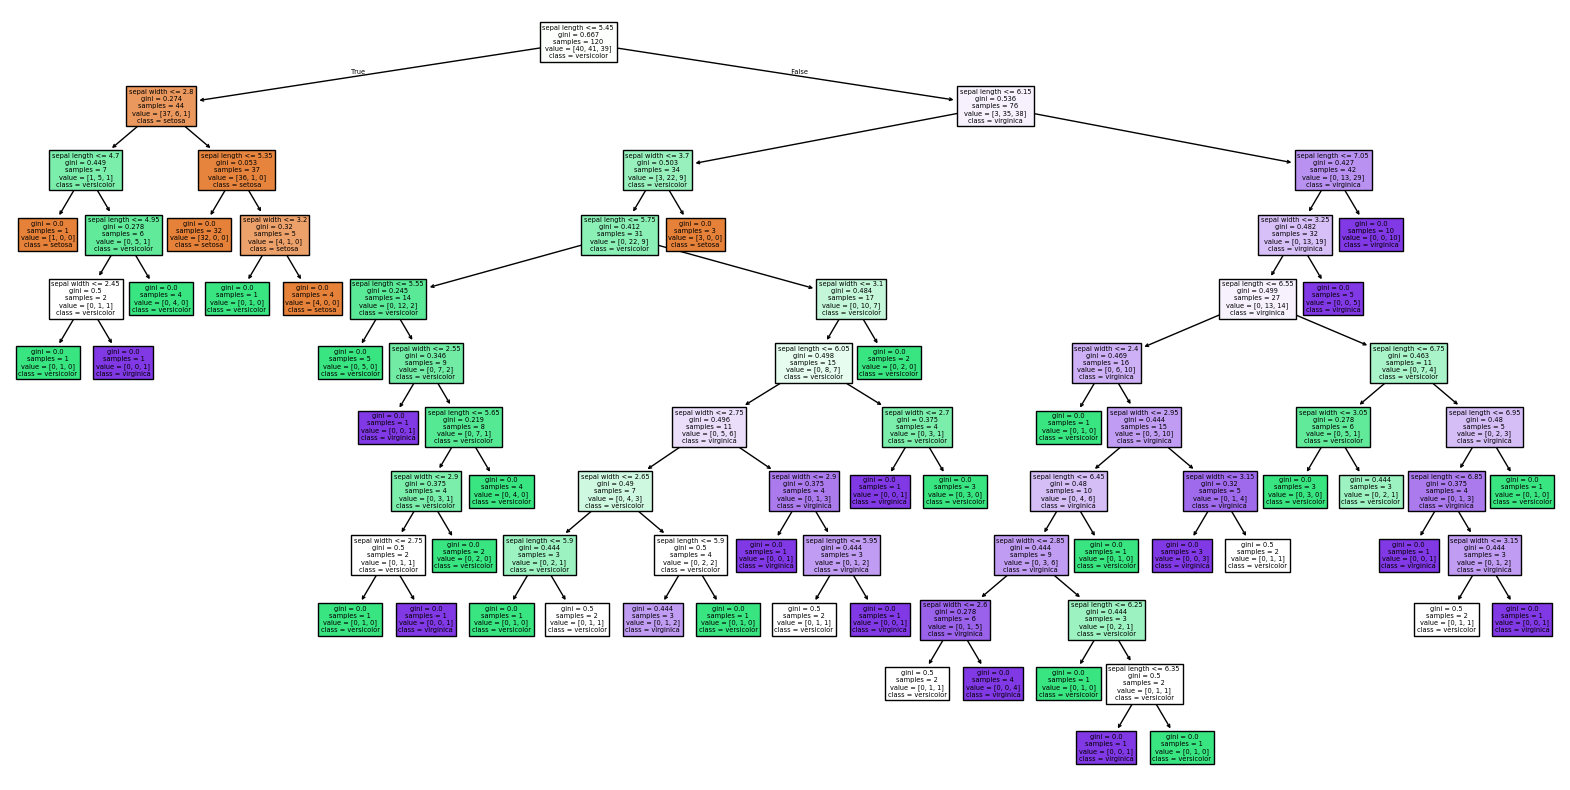

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = get_specific_features(['sepal length', 'sepal width'])

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

print_report(y_test, dtc.predict(X_test))
plt.figure(figsize=(20,10))
plot_tree(dtc, filled=True, class_names=['setosa', 'versicolor', 'virginica'], feature_names=['sepal length', 'sepal width'])
plt.show()

In [8]:
from sklearn import svm

X_train, X_test, y_train, y_test = get_specific_features(['sepal length', 'sepal width'])

svc = svm.SVC(kernel='rbf', gamma='scale')
svc.fit(X_train, y_train)

print_report(y_test, svc.predict(X_test))

Точность модели на обучающем множестве: 0.90000

Отчет о классификации:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.88      0.78      0.82         9
 Iris-virginica       0.83      0.91      0.87        11

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


Матрица ошибок:
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]


d:\python_projects\ML\lab2\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
